<a href="https://colab.research.google.com/github/S1h2l/color-image-processing-/blob/main/24MCMT14_ASSIGNMENT_IIIQ2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (6 Marks) Implement the median-cut quantisation algorithm. Use it reduce an image to 256, 128, 64, 32 and 16 colours respectively. You can try any of the images given in the previous assignment. Function prototypes:
Python: median_cut(input image, <no. of colours>) The function returns the quantised image. C/C++: int median_cut(input image, , int no. of colours)

**Cell 1: Import Libraries and Setup**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from collections import Counter
import heapq
from google.colab import files, drive
import os
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


**Cell 2: Define Median-Cut Algorithm Classes**

In [2]:
class ColorBox:
    """Represents a box (region) in RGB color space"""
    def __init__(self, pixels, indices=None):
        """
        pixels: numpy array of pixels (N x 3)
        indices: indices of pixels in this box (if None, use all)
        """
        if indices is None:
            self.indices = np.arange(len(pixels))
        else:
            self.indices = indices
        self.pixels = pixels
        self.update()

    def update(self):
        """Update box boundaries and statistics"""
        if len(self.indices) == 0:
            self.r_min = self.g_min = self.b_min = 0
            self.r_max = self.g_max = self.b_max = 0
            self.r_range = self.g_range = self.b_range = 0
            return

        box_pixels = self.pixels[self.indices]
        self.r_min = np.min(box_pixels[:, 0])
        self.r_max = np.max(box_pixels[:, 0])
        self.g_min = np.min(box_pixels[:, 1])
        self.g_max = np.max(box_pixels[:, 1])
        self.b_min = np.min(box_pixels[:, 2])
        self.b_max = np.max(box_pixels[:, 2])

        self.r_range = self.r_max - self.r_min
        self.g_range = self.g_max - self.g_min
        self.b_range = self.b_max - self.b_min


        self.centroid = np.mean(box_pixels, axis=0).astype(int)

    def get_longest_axis(self):
        """Return the color axis with the largest range"""
        ranges = [self.r_range, self.g_range, self.b_range]
        return np.argmax(ranges)

    def split(self):
        """Split this box into two along the longest axis"""
        if len(self.indices) < 2:
            return [self, None]

        axis = self.get_longest_axis()

        if axis == 0:  # Red channel
            values = self.pixels[self.indices, 0]
        elif axis == 1:  # Green channel
            values = self.pixels[self.indices, 1]
        else:  # Blue channel
            values = self.pixels[self.indices, 2]


        median = np.median(values)


        left_indices = self.indices[values <= median]
        right_indices = self.indices[values > median]

        left_box = ColorBox(self.pixels, left_indices)
        right_box = ColorBox(self.pixels, right_indices)

        return [left_box, right_box]

    def get_color(self):
        """Get the representative color for this box (centroid)"""
        return tuple(self.centroid)

class MedianCutQuantizer:
    """Median-cut color quantization algorithm"""

    def __init__(self, n_colors=256):
        """
        Initialize quantizer
        n_colors: target number of colors (must be power of 2)
        """
        self.n_colors = n_colors
        self.color_palette = None
        self.color_map = None

    def quantize(self, image):
        """
        Quantize image using median-cut algorithm

        Args:
            image: RGB image as numpy array (H, W, 3) with values 0-255

        Returns:
            quantized_image: Quantized image (H, W, 3)
            palette: Color palette used
        """

        h, w, c = image.shape
        pixels = image.reshape(-1, 3).astype(np.float32)

        initial_box = ColorBox(pixels)

        boxes = [(-len(initial_box.indices), initial_box)]
        heapq.heapify(boxes)

        current_boxes = 1
        while current_boxes < self.n_colors and boxes:

            neg_size, box = heapq.heappop(boxes)

            left_box, right_box = box.split()

            if left_box is not None and len(left_box.indices) > 0:
                heapq.heappush(boxes, (-len(left_box.indices), left_box))
                current_boxes += 1

            if right_box is not None and len(right_box.indices) > 0 and current_boxes < self.n_colors:
                heapq.heappush(boxes, (-len(right_box.indices), right_box))
                current_boxes += 1

        palette = []
        for _, box in boxes:
            if len(box.indices) > 0:
                palette.append(box.get_color())

        while len(palette) < self.n_colors:
            palette.append(palette[-1])

        self.color_palette = np.array(palette, dtype=np.uint8)

        quantized_pixels = np.zeros_like(pixels, dtype=np.uint8)

        for i, pixel in enumerate(pixels):

            distances = np.sqrt(np.sum((self.color_palette - pixel) ** 2, axis=1))
            closest_idx = np.argmin(distances)
            quantized_pixels[i] = self.color_palette[closest_idx]

        quantized_image = quantized_pixels.reshape(h, w, 3)

        return quantized_image, self.color_palette

def median_cut(image, n_colors):
    """
    Wrapper function for median-cut quantization

    Args:
        image: RGB image as numpy array (H, W, 3) or file path
        n_colors: number of colors for quantization

    Returns:
        quantized_image: Quantized image
    """
    if isinstance(image, str):
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)

    quantizer = MedianCutQuantizer(n_colors)

    quantized_image, palette = quantizer.quantize(image)

    return quantized_image

print("Median-Cut algorithm implemented successfully!")

Median-Cut algorithm implemented successfully!


**Cell 3: Upload or Load Test Images**

In [3]:
class ColorBox:
    def __init__(self, pixels):
        self.pixels = pixels
        self.indices = np.arange(len(pixels))
        self.update()

    def update(self):
        if len(self.indices) == 0:
            self.r_min = self.g_min = self.b_min = 0
            self.r_max = self.g_max = self.b_max = 0
            self.size = 0
            return

        box_pixels = self.pixels[self.indices]
        self.r_min = np.min(box_pixels[:, 0])
        self.r_max = np.max(box_pixels[:, 0])
        self.g_min = np.min(box_pixels[:, 1])
        self.g_max = np.max(box_pixels[:, 1])
        self.b_min = np.min(box_pixels[:, 2])
        self.b_max = np.max(box_pixels[:, 2])

        self.r_range = self.r_max - self.r_min
        self.g_range = self.g_max - self.g_min
        self.b_range = self.b_max - self.b_min

        self.centroid = np.mean(box_pixels, axis=0).astype(int)
        self.size = len(self.indices)

    def get_longest_axis(self):
        ranges = [self.r_range, self.g_range, self.b_range]
        return np.argmax(ranges)

    def split(self):
        if len(self.indices) < 2:
            return [self, None]

        axis = self.get_longest_axis()

        if axis == 0:
            values = self.pixels[self.indices, 0]
        elif axis == 1:
            values = self.pixels[self.indices, 1]
        else:
            values = self.pixels[self.indices, 2]

        median = np.median(values)

        left_indices = self.indices[values <= median]
        right_indices = self.indices[values > median]

        left_box = ColorBox(self.pixels)
        left_box.indices = left_indices
        left_box.update()

        right_box = ColorBox(self.pixels)
        right_box.indices = right_indices
        right_box.update()

        return [left_box, right_box]

    def get_color(self):
        return tuple(self.centroid)

def median_cut(image, n_colors):
    """Apply median-cut quantization"""

    if isinstance(image, str):
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)


    h, w, c = image.shape
    pixels = image.reshape(-1, 3).astype(np.float32)


    boxes = [ColorBox(pixels)]

    while len(boxes) < n_colors:

        max_size_idx = 0
        for i in range(1, len(boxes)):
            if boxes[i].size > boxes[max_size_idx].size:
                max_size_idx = i

        box_to_split = boxes[max_size_idx]
        left_box, right_box = box_to_split.split()

        boxes.pop(max_size_idx)
        if left_box is not None and left_box.size > 0:
            boxes.append(left_box)
        if right_box is not None and right_box.size > 0:
            boxes.append(right_box)


        if len(boxes) >= n_colors * 2:
            break

    palette = np.array([box.get_color() for box in boxes], dtype=np.uint8)


    while len(palette) < n_colors:
        palette = np.vstack([palette, palette[-1]])
    palette = palette[:n_colors]


    quantized_pixels = np.zeros_like(pixels, dtype=np.uint8)

    batch_size = 5000
    for i in range(0, len(pixels), batch_size):
        batch = pixels[i:i+batch_size]

        distances = np.zeros((len(batch), len(palette)))
        for j, color in enumerate(palette):
            distances[:, j] = np.sqrt(((batch - color) ** 2).sum(axis=1))
        closest_idx = np.argmin(distances, axis=1)
        quantized_pixels[i:i+batch_size] = palette[closest_idx]


    quantized_image = quantized_pixels.reshape(h, w, c)

    return quantized_image, palette

print("✓ Median-Cut algorithm ready!")

✓ Median-Cut algorithm ready!


**Cell 3: Test the Algorithm**

In [4]:
print("Testing algorithm with small sample...")


test_img = np.random.randint(0, 255, (50, 50, 3), dtype=np.uint8)

try:

    quantized_test, palette_test = median_cut(test_img, 16)
    print(f"✓ Algorithm works! Output shape: {quantized_test.shape}")
    print(f"✓ Palette size: {len(palette_test)}")
    print(f"✓ Unique colors in output: {len(np.unique(quantized_test.reshape(-1, 3), axis=0))}")
except Exception as e:
    print(f"✗ Error: {e}")

print("\n✓ Ready to process your image!")

Testing algorithm with small sample...
✓ Algorithm works! Output shape: (50, 50, 3)
✓ Palette size: 16
✓ Unique colors in output: 16

✓ Ready to process your image!


LOADING YOUR IMAGE
✓ Image found at: /content/OIP (3).jpg
✓ Image loaded successfully!
  Shape: (180, 288, 3)
  Height: 180 pixels
  Width: 288 pixels
  Total pixels: 51,840
  Data type: uint8


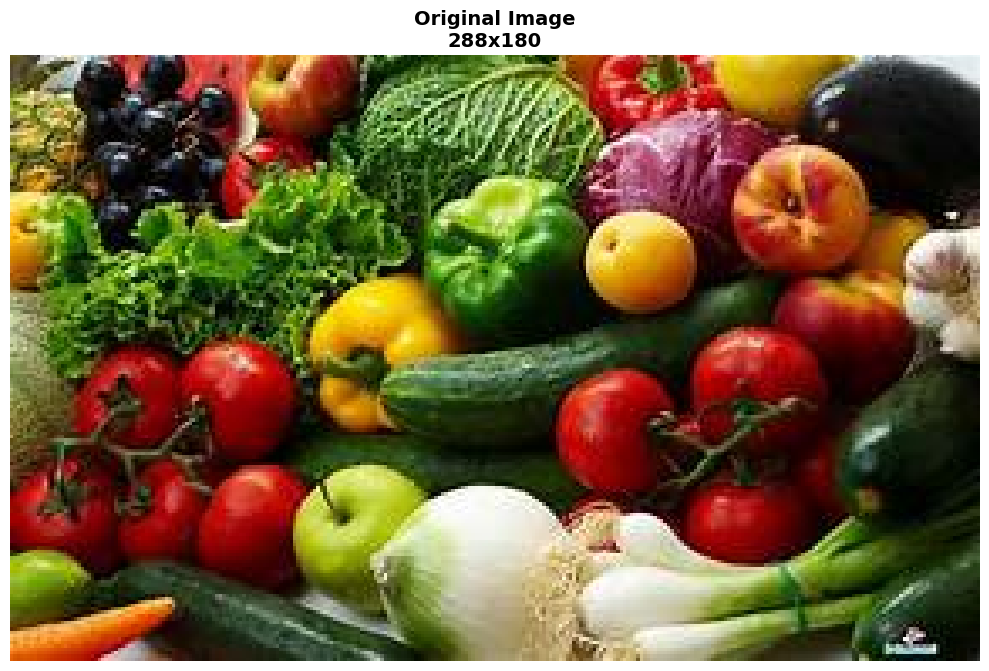

In [6]:
print("=" * 80)
print("LOADING YOUR IMAGE")
print("=" * 80)


image_path = "/content/OIP (3).jpg"


import os
if os.path.exists(image_path):
    print(f"✓ Image found at: {image_path}")
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"✓ Image loaded successfully!")
    print(f"  Shape: {image.shape}")
    print(f"  Height: {image.shape[0]} pixels")
    print(f"  Width: {image.shape[1]} pixels")
    print(f"  Total pixels: {image.shape[0] * image.shape[1]:,}")
    print(f"  Data type: {image.dtype}")
else:
    print(f"✗ Image not found at: {image_path}")
    print("Please upload the image or check the path")

    print("\nFiles in /content:")
    for f in os.listdir('/content'):
        if f.endswith(('.jpg', '.jpeg', '.png', '.JPG')):
            print(f"  - {f}")


plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.title(f"Original Image\n{image.shape[1]}x{image.shape[0]}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**Cell 5: Apply Median-Cut Quantization**

In [11]:

print("=" * 80)
print("APPLYING MEDIAN-CUT QUANTIZATION")
print("=" * 80)


color_counts = [256, 128, 64, 32, 16]
quantized_images = {}
palettes = {}
processing_times = {}

for n_colors in color_counts:
    print(f"\n{'='*50}")
    print(f"  Quantizing to {n_colors} colors...")
    print(f"{'='*50}")

    start_time = time.time()
    quantized, palette = median_cut(image.copy(), n_colors)
    elapsed_time = time.time() - start_time

    quantized_images[n_colors] = quantized
    palettes[n_colors] = palette
    processing_times[n_colors] = elapsed_time


    unique_colors = len(np.unique(quantized.reshape(-1, 3), axis=0))


    bits_per_pixel = np.log2(n_colors)
    original_bits = 24
    compression_ratio = original_bits / bits_per_pixel

    print(f"  ✓ Unique colors in result: {unique_colors}")
    print(f"  ✓ Bits per pixel: {bits_per_pixel:.2f}")
    print(f"  ✓ Compression ratio: {compression_ratio:.2f}:1")
    print(f"  ✓ Processing time: {elapsed_time:.2f} seconds")

print("\n✓ All quantizations completed!")

APPLYING MEDIAN-CUT QUANTIZATION

  Quantizing to 256 colors...
  ✓ Unique colors in result: 256
  ✓ Bits per pixel: 8.00
  ✓ Compression ratio: 3.00:1
  ✓ Processing time: 2.26 seconds

  Quantizing to 128 colors...
  ✓ Unique colors in result: 128
  ✓ Bits per pixel: 7.00
  ✓ Compression ratio: 3.43:1
  ✓ Processing time: 1.30 seconds

  Quantizing to 64 colors...
  ✓ Unique colors in result: 64
  ✓ Bits per pixel: 6.00
  ✓ Compression ratio: 4.00:1
  ✓ Processing time: 0.59 seconds

  Quantizing to 32 colors...
  ✓ Unique colors in result: 32
  ✓ Bits per pixel: 5.00
  ✓ Compression ratio: 4.80:1
  ✓ Processing time: 0.30 seconds

  Quantizing to 16 colors...
  ✓ Unique colors in result: 16
  ✓ Bits per pixel: 4.00
  ✓ Compression ratio: 6.00:1
  ✓ Processing time: 0.16 seconds

✓ All quantizations completed!


**Cell 6: Display Results**


VISUALIZING RESULTS


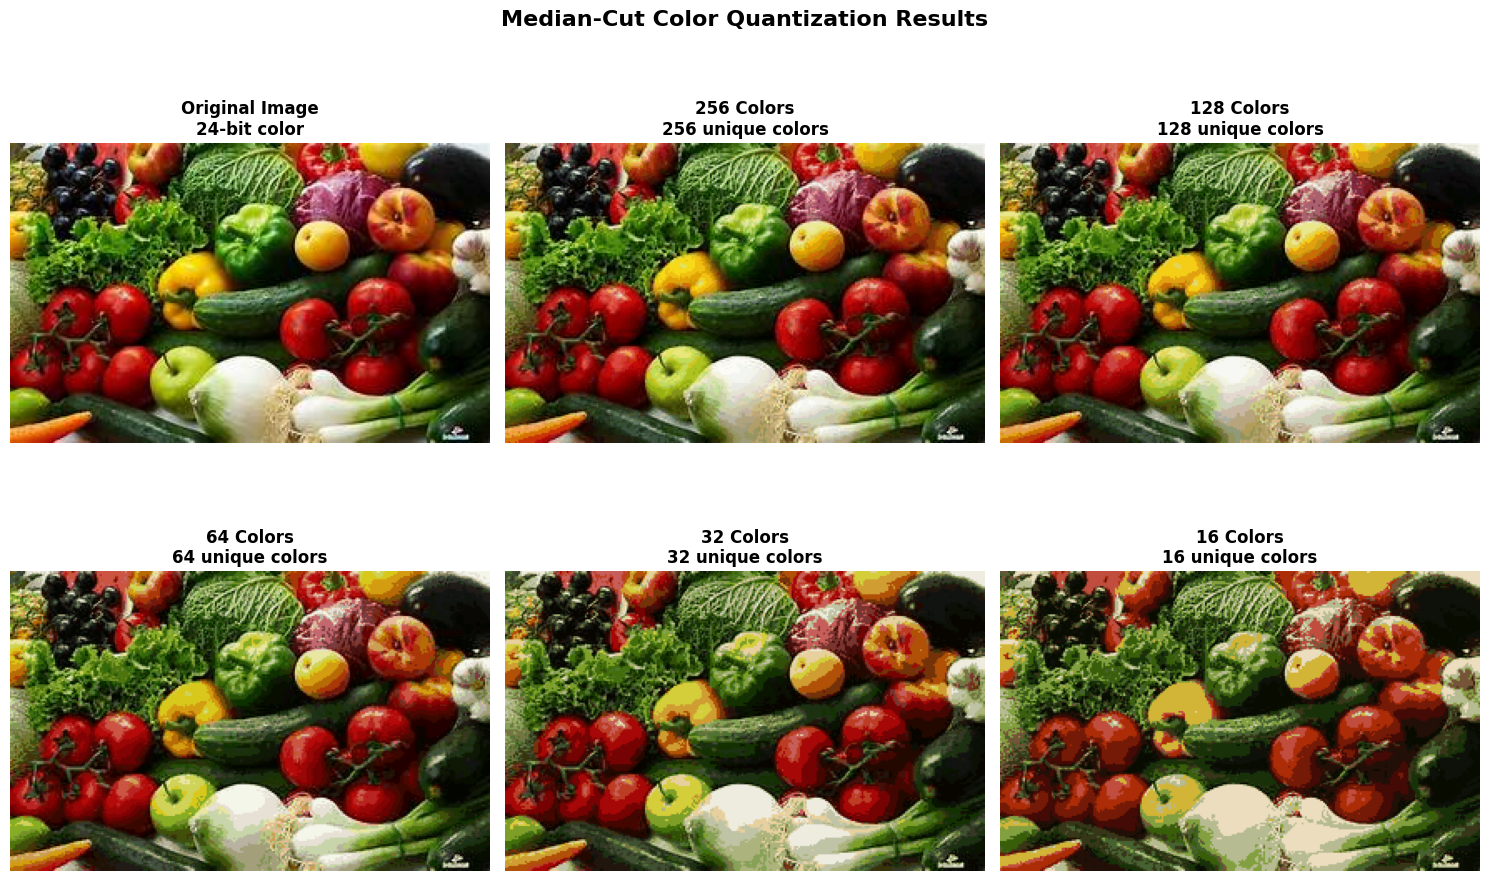

In [12]:

print("\n" + "=" * 80)
print("VISUALIZING RESULTS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()


axes[0].imshow(image)
axes[0].set_title(f"Original Image\n24-bit color", fontsize=12, fontweight='bold')
axes[0].axis('off')

for idx, n_colors in enumerate(color_counts, 1):
    axes[idx].imshow(quantized_images[n_colors])
    unique_colors = len(np.unique(quantized_images[n_colors].reshape(-1, 3), axis=0))
    axes[idx].set_title(f"{n_colors} Colors\n{unique_colors} unique colors",
                       fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Median-Cut Color Quantization Results", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Cell 7: Quality Metrics**


QUALITY METRICS

256 COLORS:
  PSNR: 31.17 dB
  MSE: 49.70
  Unique colors: 256
  Time: 2.26s

128 COLORS:
  PSNR: 29.08 dB
  MSE: 80.42
  Unique colors: 128
  Time: 1.30s

64 COLORS:
  PSNR: 26.93 dB
  MSE: 131.71
  Unique colors: 64
  Time: 0.59s

32 COLORS:
  PSNR: 24.82 dB
  MSE: 214.55
  Unique colors: 32
  Time: 0.30s

16 COLORS:
  PSNR: 22.59 dB
  MSE: 357.78
  Unique colors: 16
  Time: 0.16s


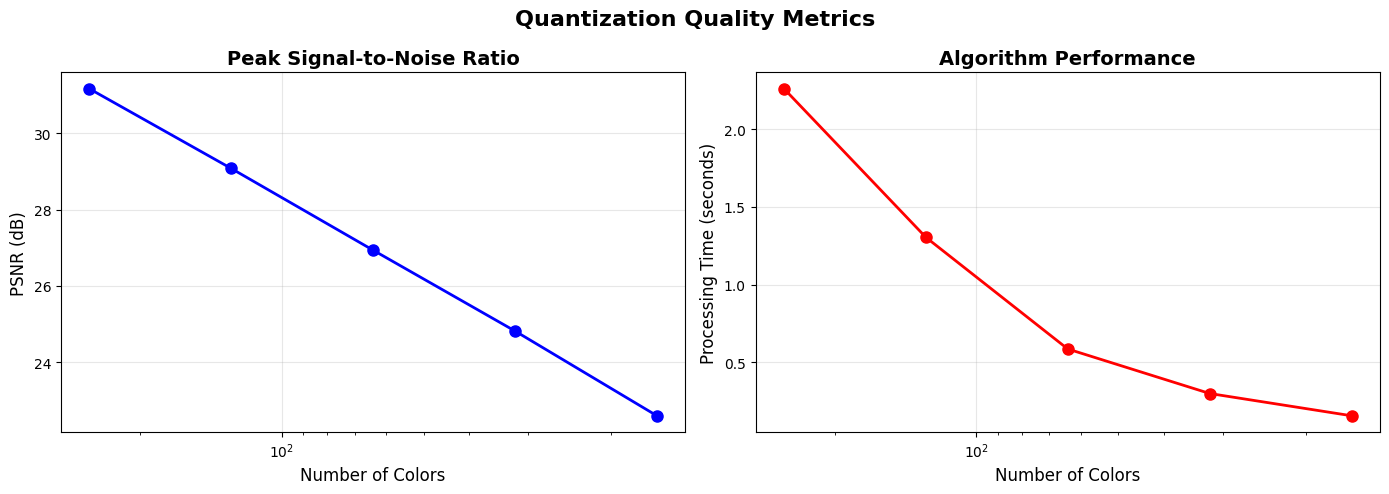

In [13]:

print("\n" + "=" * 80)
print("QUALITY METRICS")
print("=" * 80)

metrics = []

for n_colors in color_counts:
    quantized = quantized_images[n_colors]

    mse = np.mean((image.astype(float) - quantized.astype(float)) ** 2)

    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))


    unique_colors = len(np.unique(quantized.reshape(-1, 3), axis=0))

    metrics.append({
        'colors': n_colors,
        'psnr': psnr,
        'mse': mse,
        'unique_colors': unique_colors,
        'time': processing_times[n_colors]
    })

    print(f"\n{n_colors} COLORS:")
    print(f"  PSNR: {psnr:.2f} dB")
    print(f"  MSE: {mse:.2f}")
    print(f"  Unique colors: {unique_colors}")
    print(f"  Time: {processing_times[n_colors]:.2f}s")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = [m['colors'] for m in metrics]
psnr_values = [m['psnr'] for m in metrics]
time_values = [m['time'] for m in metrics]

axes[0].plot(colors_list, psnr_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Colors', fontsize=12)
axes[0].set_ylabel('PSNR (dB)', fontsize=12)
axes[0].set_title('Peak Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')
axes[0].invert_xaxis()

axes[1].plot(colors_list, time_values, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Colors', fontsize=12)
axes[1].set_ylabel('Processing Time (seconds)', fontsize=12)
axes[1].set_title('Algorithm Performance', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')
axes[1].invert_xaxis()

plt.suptitle('Quantization Quality Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Cell 8: Zoomed Comparison**


ZOOMED DETAIL COMPARISON


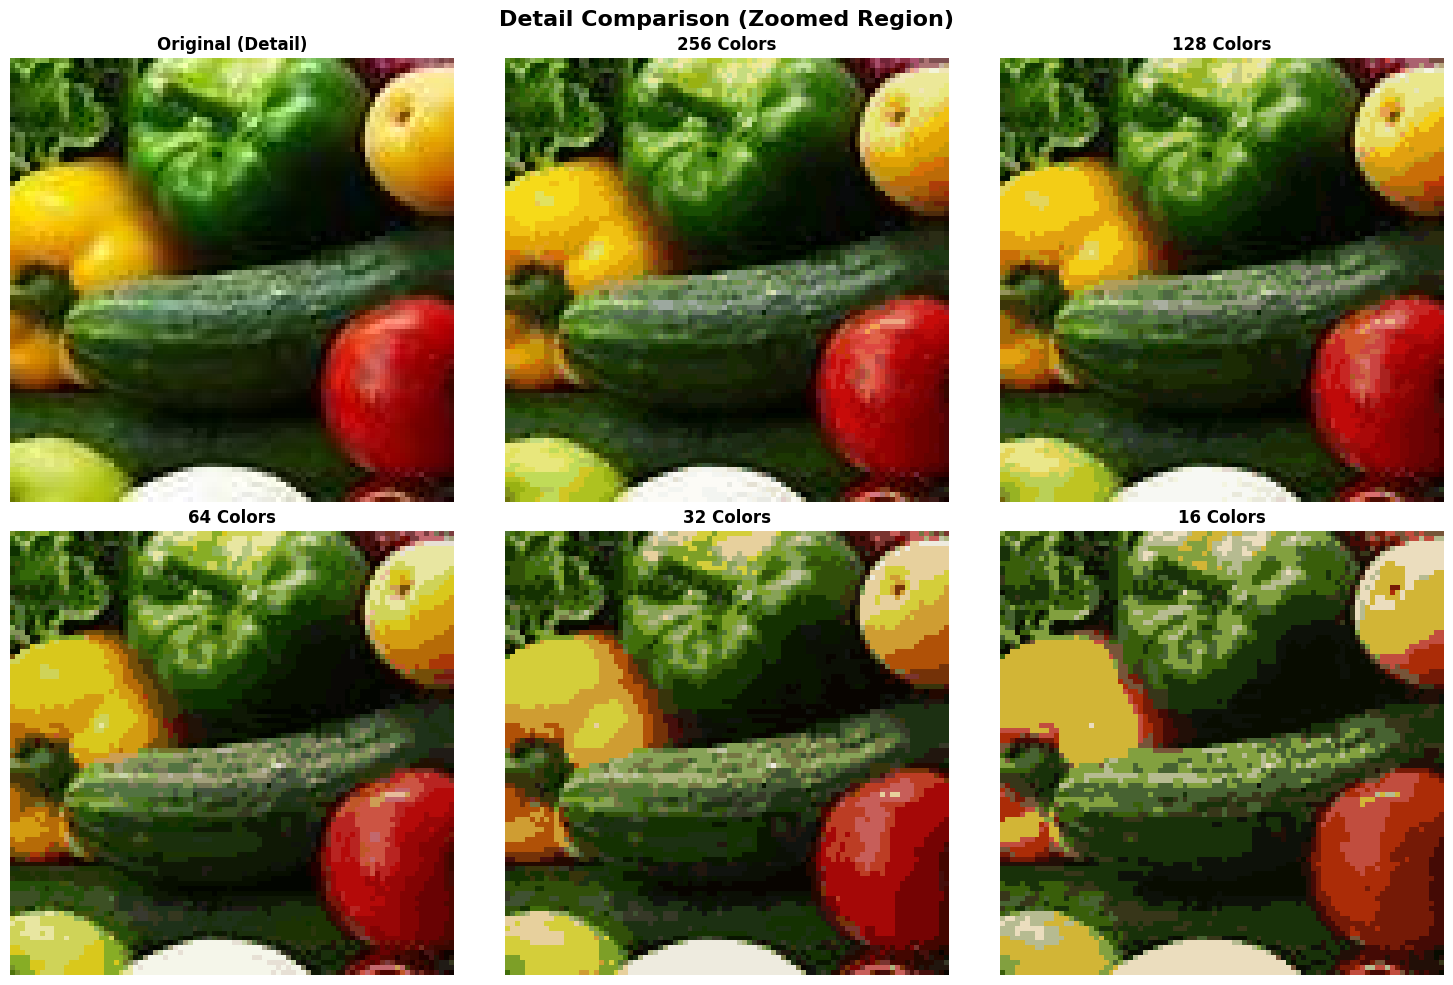

In [14]:
print("\n" + "=" * 80)
print("ZOOMED DETAIL COMPARISON")
print("=" * 80)


h, w = image.shape[:2]
zoom_size = min(150, h//2, w//2)
start_h = h//2 - zoom_size//2
start_w = w//2 - zoom_size//2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()


original_zoom = image[start_h:start_h+zoom_size, start_w:start_w+zoom_size]
axes[0].imshow(original_zoom)
axes[0].set_title(f"Original (Detail)", fontsize=12, fontweight='bold')
axes[0].axis('off')

for idx, n_colors in enumerate(color_counts, 1):
    quantized_zoom = quantized_images[n_colors][start_h:start_h+zoom_size, start_w:start_w+zoom_size]
    axes[idx].imshow(quantized_zoom)
    axes[idx].set_title(f"{n_colors} Colors", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Detail Comparison (Zoomed Region)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Cell 9: Save Results**

In [15]:
print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

save_dir = 'quantized_results'
os.makedirs(save_dir, exist_ok=True)

original_path = os.path.join(save_dir, 'original.jpg')
Image.fromarray(image).save(original_path)
print(f"✓ Saved original to: {original_path}")

for n_colors in color_counts:
    quantized = quantized_images[n_colors]
    save_path = os.path.join(save_dir, f'quantized_{n_colors}_colors.jpg')
    Image.fromarray(quantized).save(save_path)
    print(f"✓ Saved {n_colors} colors to: {save_path}")

print(f"\n All results saved in '{save_dir}' folder")


SAVING RESULTS
✓ Saved original to: quantized_results/original.jpg
✓ Saved 256 colors to: quantized_results/quantized_256_colors.jpg
✓ Saved 128 colors to: quantized_results/quantized_128_colors.jpg
✓ Saved 64 colors to: quantized_results/quantized_64_colors.jpg
✓ Saved 32 colors to: quantized_results/quantized_32_colors.jpg
✓ Saved 16 colors to: quantized_results/quantized_16_colors.jpg

 All results saved in 'quantized_results' folder
